# Exploratory Data Analysis

In [2]:
from ds_salary_prediction.paths import DATASET_PATH
import pandas as pd

In [4]:
df = pd.read_csv(DATASET_PATH)

In [5]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
3,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
4,2022,SE,FT,Lead Machine Learning Engineer,7500000,INR,95386,IN,50,IN,L


In [5]:
print(df.info())
print("------------------------------------------------")
print(df.nunique())


<class 'pandas.DataFrame'>
RangeIndex: 14838 entries, 0 to 14837
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           14838 non-null  int64
 1   experience_level    14838 non-null  str  
 2   employment_type     14838 non-null  str  
 3   job_title           14838 non-null  str  
 4   salary              14838 non-null  int64
 5   salary_currency     14838 non-null  str  
 6   salary_in_usd       14838 non-null  int64
 7   employee_residence  14838 non-null  str  
 8   remote_ratio        14838 non-null  int64
 9   company_location    14838 non-null  str  
 10  company_size        14838 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.2 MB
None
------------------------------------------------
work_year                5
experience_level         4
employment_type          4
job_title              153
salary                2363
salary_currency         23
salary_in_usd         2730
em

In [6]:
print(df["work_year"].value_counts())
print("------------------------------------------------")
print(df["experience_level"].value_counts())
print("------------------------------------------------")
print(df["employment_type"].value_counts())
print("------------------------------------------------")
print(df["remote_ratio"].value_counts())
print("------------------------------------------------")
print(df["company_size"].value_counts())

work_year
2023    8519
2024    4374
2022    1652
2021     218
2020      75
Name: count, dtype: int64
------------------------------------------------
experience_level
SE    9696
MI    3553
EN    1148
EX     441
Name: count, dtype: int64
------------------------------------------------
employment_type
FT    14772
PT       27
CT       26
FL       13
Name: count, dtype: int64
------------------------------------------------
remote_ratio
0      9853
100    4737
50      248
Name: count, dtype: int64
------------------------------------------------
company_size
M    13674
L      983
S      181
Name: count, dtype: int64


In [7]:
print(df["job_title"].value_counts().head(15))
print("------------------------------------------------")
print(df["employee_residence"].value_counts().head(15))
print("------------------------------------------------")
print(df["company_location"].value_counts().head(15))
print("------------------------------------------------")

job_title
Data Engineer                     3162
Data Scientist                    3015
Data Analyst                      2189
Machine Learning Engineer         1542
Research Scientist                 475
Analytics Engineer                 403
Applied Scientist                  383
Data Architect                     369
Research Engineer                  276
Business Intelligence Engineer     230
Data Science                       205
Data Manager                       188
ML Engineer                        163
Business Intelligence Analyst      147
Machine Learning Scientist         124
Name: count, dtype: int64
------------------------------------------------
employee_residence
US    12926
GB      647
CA      390
ES      131
DE       91
IN       74
FR       65
AU       50
PT       30
NL       28
BR       23
IT       21
GR       17
CO       16
LT       16
Name: count, dtype: int64
------------------------------------------------
company_location
US    12975
GB      655
CA      392
ES 

In [8]:
df["job_title"].value_counts().describe()

count     153.000000
mean       96.980392
std       412.383484
min         1.000000
25%         2.000000
50%         7.000000
75%        24.000000
max      3162.000000
Name: count, dtype: float64

In [9]:
df.duplicated().sum()

np.int64(5711)

##### Duplicate check: 5,711 rows are duplicates of an earlier identical row across all columns. This represents a substantial portion of the dataset and requires further investigation before deciding whether duplicates should be removed.

In [10]:
df.duplicated(keep=False).sum()

np.int64(7949)

In [11]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,14838.000000,1.483800e+04,14838.000000,14838.000000
mean,2023.138900,1.650227e+05,149874.718763,32.760480
std,0.700799,3.562354e+05,69009.181349,46.488278
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.021000e+05,102000.000000,0.000000
50%,2023.000000,1.422000e+05,141300.000000,0.000000
75%,2024.000000,1.875000e+05,185900.000000,100.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


In [12]:
salary = df.nlargest(100, "salary_in_usd")
salary["salary_in_usd"].describe()

count       100.000000
mean     484216.340000
std      136221.729146
min      370000.000000
25%      385000.000000
50%      430803.500000
75%      535000.000000
max      800000.000000
Name: salary_in_usd, dtype: float64

In [13]:
df["salary_in_usd"].skew()

np.float64(1.52278464556912)

In [14]:
duplicate_counts = df.value_counts()
duplicate_counts.describe()
duplicate_counts.value_counts().sort_index()
df[df.duplicated(keep=False)].value_counts().head(1)

work_year  experience_level  employment_type  job_title          salary  salary_currency  salary_in_usd  employee_residence  remote_ratio  company_location  company_size
2023       SE                FT               Applied Scientist  136000  USD              136000         US                  0             US                L               54
Name: count, dtype: int64

##### Exact duplicates are substantial; some observations are repeated many times (maximum 54). Exact duplicate rows will be removed before model splitting to avoid artificial weighting and potential train/test contamination.

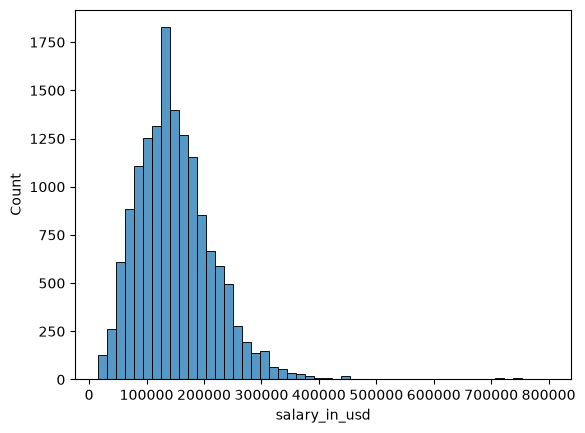

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x="salary_in_usd", bins=50)
plt.show()

In [16]:
df.nlargest(20, "salary_in_usd")[
    [
        "salary_in_usd",
        "job_title",
        "experience_level",
        "employment_type",
        "work_year",
        "company_location",
        "company_size"
    ]
]

,salary_in_usd,job_title,experience_level,employment_type,work_year,company_location,company_size
66,800000,AI Architect,MI,FT,2024,CA,M
68,774000,Data Analyst,EN,FT,2024,MX,M
69,750000,Analytics Engineer,SE,FT,2024,US,M
70,750000,Machine Learning Scientist,MI,FT,2024,US,M
71,750000,Data Analyst,SE,FT,2024,US,M
72,750000,Machine Learning Scientist,MI,FT,2024,US,M
73,750000,Machine Learning Scientist,MI,FT,2023,US,M
74,750000,Machine Learning Engineer,MI,FT,2023,US,M
75,750000,Data Engineer,MI,FT,2023,US,M
76,750000,Data Scientist,SE,FT,2023,US,M


In [17]:
print(f"mean: {df.groupby('experience_level')['salary_in_usd'].mean()}")
print(f"median: {df.groupby('experience_level')['salary_in_usd'].median()}")

mean: experience_level
EN     91656.841463
EX    194730.210884
MI    125386.553054
SE    163700.967100
Name: salary_in_usd, dtype: float64
median: experience_level
EN     83000.0
EX    191857.0
MI    114800.0
SE    155000.0
Name: salary_in_usd, dtype: float64


#### There is a strong observed association between experience level and salary in this dataset.

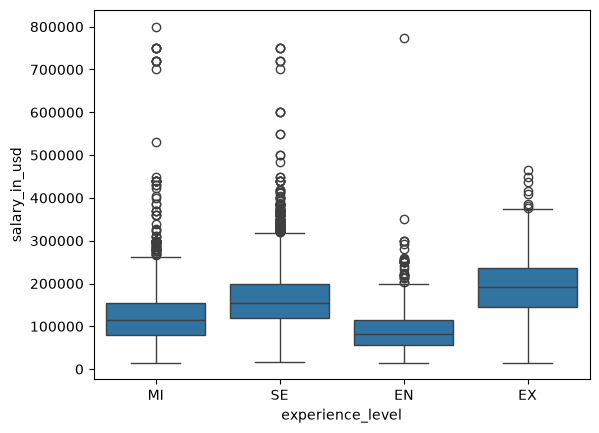

In [18]:
sns.boxplot(data=df, x="experience_level", y="salary_in_usd")
plt.show()

In [19]:
df.nlargest(20, "salary_in_usd")
df["work_year"].value_counts()

work_year
2023    8519
2024    4374
2022    1652
2021     218
2020      75
Name: count, dtype: int64

In [20]:
print(df.groupby("company_size")["salary_in_usd"].agg(["mean", "median", "count"]))
print("----------------")
top_job = df["job_title"].value_counts().head(10).index
print(df[df["job_title"].isin(top_job)].groupby("job_title")["salary_in_usd"].agg(
    ["mean", "median", "count"]).sort_values("median", ascending=False))

                       mean    median  count
company_size                                
L             139602.460834  136000.0    983
M             151450.535396  143150.0  13674
S              86614.569061   70179.0    181
----------------
                                         mean    median  count
job_title                                                     
Applied Scientist               190350.707572  192000.0    383
Machine Learning Engineer       188014.814527  184700.0   1542
Research Scientist              194217.117895  180000.0    475
Research Engineer               190154.568841  169056.0    276
Data Architect                  163499.723577  155000.0    369
Data Scientist                  154179.810945  150120.0   3015
Analytics Engineer              159616.397022  147000.0    403
Business Intelligence Engineer  140673.973913  140500.0    230
Data Engineer                   146780.174257  140000.0   3162
Data Analyst                    108031.788945  103200.0   2189


In [21]:
print(df.groupby("work_year")["salary_in_usd"].agg(["mean", "median", "count"]))
print(df.groupby("remote_ratio")["salary_in_usd"].agg(["mean", "median", "count"]))

                    mean    median  count
work_year                                
2020       102250.866667   79833.0     75
2021        99922.073394   83872.0    218
2022       134404.072034  132000.0   1652
2023       153732.664632  145000.0   8519
2024       151510.094422  140000.0   4374
                       mean    median  count
remote_ratio                                
0             153847.453669  143800.0   9853
50             83056.983871   66107.0    248
100           145109.559637  140000.0   4737


In [22]:
top_locations = df["company_location"].value_counts().head(10).index

print(df[df["company_location"].isin(top_locations)].groupby(
    "company_location"
)["salary_in_usd"].agg(["mean", "median", "count"]).sort_values(
    "median", ascending=False
))
top_locations = df["employee_residence"].value_counts().head(10).index

print(df[df["employee_residence"].isin(top_locations)].groupby(
    "employee_residence"
)["salary_in_usd"].agg(["mean", "median", "count"]).sort_values(
    "median", ascending=False
))

                           mean    median  count
company_location                                
US                157410.126474  148000.0  12975
CA                145174.987245  139250.0    392
AU                130126.471698  105000.0     53
GB                 95321.219847   80036.0    655
DE                 92163.959184   76240.5     98
NL                 76171.821429   74561.5     28
FR                 86310.508197   64781.0     61
ES                 56817.149606   48585.0    127
PT                 50253.892857   45886.0     28
IN                 41995.423729   30428.0     59
                             mean    median  count
employee_residence                                
US                  157701.911032  148500.0  12926
CA                  145654.802564  139250.0    390
AU                  132666.760000  105600.0     50
GB                   95651.272025   80036.0    647
DE                   97455.582418   79653.0     91
NL                   76752.964286   74561.5     28
FR  

## جمع‌بندی EDA و پیامدهای مدل‌سازی

در این EDA، ابتدا ساختار و ویژگی‌های dataset بررسی شد و سپس کیفیت داده، cardinality، distribution، مقادیر extreme و رابطه‌ی featureها با `salary_in_usd` مورد بررسی قرار گرفت.

### 1. شناخت اولیه Dataset

Dataset شامل **14,838 رکورد و 11 ستون** است.

در این پروژه، `salary_in_usd` به عنوان **target (`y`)** انتخاب می‌شود.

Featureهای کاندید برای مدل:

* `work_year`
* `experience_level`
* `employment_type`
* `job_title`
* `employee_residence`
* `remote_ratio`
* `company_location`
* `company_size`

ستون‌های `salary` و `salary_currency` در `X` استفاده نخواهند شد؛ زیرا `salary` همان مقدار salary را در currency محلی ثبت می‌کند و `salary_currency` واحد آن را مشخص می‌کند، در حالی که target موردنظر ما `salary_in_usd` است.

### 2. Data Quality

در بررسی اولیه با `df.info()`، برای تمام 11 ستون تعداد `Non-Null` برابر با تعداد کل رکوردها بود؛ بنابراین **missing value از نوع NA/None در بررسی اولیه مشاهده نشد**.

Dataset دارای تعداد قابل توجهی `exact duplicate` است:

* تعداد occurrenceهای اضافه‌ی duplicate: **5,711**
* تعداد ردیف‌های متمایز پس از در نظر گرفتن exact duplicates: **9,127**
* تعداد گروه‌های duplicate: **2,238**
* بیشترین تکرار یک ردیف کاملاً یکسان: **54 بار**

بیشتر ردیف‌های متمایز فقط یک بار ظاهر شدند، اما تعدادی از گروه‌ها چندین بار تکرار شده‌اند.

برای V1، `exact duplicate`ها قبل از تقسیم داده برای مدل‌سازی حذف خواهند شد تا occurrenceهای کاملاً یکسان وزن مصنوعی به برخی observationها ندهند و ریسک قرارگرفتن رکوردهای یکسان در بخش‌های مختلف داده کاهش یابد.

### 3. Feature Cardinality و Imbalance

Cardinality ویژگی‌ها بسیار متفاوت است.

`job_title` دارای **153 category** است و توزیع تعداد نمونه‌ها بین categoryها به‌شدت نامتوازن و long-tailed است. برای این feature، تعداد نمونه‌های هر category از **1 تا 3,162** متغیر است و median تعداد نمونه برای هر job title فقط **7** است.

`employee_residence` دارای **88 category** و `company_location` دارای **77 category** هستند و هر دو به‌شدت تحت سلطه‌ی `US` قرار دارند.

برخی featureهای کم‌cardinality نیز شدیداً نامتوازن‌اند:

* `employment_type`: تعداد `FT` برابر **14,772** از 14,838 رکورد است.
* `company_size`: تعداد `M` برابر **13,674** است.
* `work_year`: بیشتر داده‌ها مربوط به 2023 و 2024 هستند.
* `experience_level`: بیشتر رکوردها در `SE` و `MI` قرار دارند.
* `remote_ratio`: مقدار `0` بیشترین فراوانی را دارد و مقدار `50` بسیار کم‌تعداد است.

این imbalanceها به‌تنهایی دلیل حذف feature نیستند و تصمیم نهایی درباره‌ی encoding و usefulness آن‌ها در مرحله‌ی modeling و validation گرفته خواهد شد.

### 4. Target Analysis

توزیع `salary_in_usd` دارای **positive/right skewness** است و مقدار skewness تقریباً **1.52** به دست آمد.

آمار اصلی target:

* Mean ≈ **149,875 USD**
* Median = **141,300 USD**
* Minimum = **15,000 USD**
* Maximum = **800,000 USD**

هیستوگرام نیز نشان داد بخش عمده‌ی داده‌ها در محدوده‌ی پایین‌تر از extreme values متمرکز است و یک right tail قابل توجه وجود دارد.

مقادیر extreme تا `800,000 USD` مشاهده شدند. بررسی 20 رکورد با بالاترین salary نشان داد که این مقادیر در نقش‌ها و سطوح مختلف تجربه دیده می‌شوند و بعضی از آن‌ها در context داده کاملاً نامعقول به نظر نمی‌رسند.

با این حال، موارد بسیار مشکوک نیز مشاهده شد؛ برای مثال رکورد `Data Analyst` با سطح `EN` و salary برابر `774,000 USD`.

در این مرحله، صرفاً بر اساس outlier بودن آماری، هیچ extreme value حذف نمی‌شود. بنابراین target در baseline اولیه بدون trimming یا transformation استفاده خواهد شد.

### 5. Feature–Target Relationships

در بررسی رابطه‌ی featureها با `salary_in_usd`، چند الگوی قابل مشاهده پیدا شد.

`experience_level` رابطه‌ی مشخصی با salary نشان داد. Median salary از حدود:

`EN → 83,000`

به:

`MI → 114,800`

سپس:

`SE → 155,000`

و:

`EX → 191,857`

افزایش پیدا کرد.

`company_size` نیز تفاوت قابل مشاهده‌ای در salary داشت:

* `S`: median ≈ **70,179 USD**
* `M`: median ≈ **143,150 USD**
* `L`: median ≈ **136,000 USD**

`job_title` نیز association قابل توجهی با salary نشان داد. در بین 10 عنوان پرتکرار بررسی‌شده، median salary از حدود **103,200 USD** برای `Data Analyst` تا حدود **192,000 USD** برای `Applied Scientist` متفاوت بود.

`work_year`، `remote_ratio`، `company_location` و `employee_residence` نیز بین categoryهای خود تفاوت‌های قابل مشاهده‌ای در salary نشان دادند.

این یافته‌ها بیانگر **observed association** هستند و به معنی اثبات رابطه‌ی causal نیستند. همچنین feature importance واقعی تا زمان آموزش و ارزیابی مدل مشخص نخواهد شد.

### 6. Modeling Implications

بر اساس یافته‌های این EDA، در مرحله‌ی modeling:

* `salary_in_usd` به عنوان `y` استفاده خواهد شد.
* `salary` و `salary_currency` در `X` قرار نخواهند گرفت.
* exact duplicateها قبل از model splitting حذف خواهند شد.
* featureهای categorical با توجه به cardinality و rare categories نیازمند encoding مناسب هستند، به‌خصوص `job_title`، `employee_residence` و `company_location`.
* imbalance به‌تنهایی باعث حذف featureها نخواهد شد.
* `salary_in_usd` در baseline اولیه بدون حذف extreme values و بدون transformation استفاده خواهد شد.
* ابتدا یک baseline ساده ساخته و ارزیابی می‌شود؛ سپس فقط در صورت وجود evidence کافی، preprocessing یا transformationهای پیچیده‌تر بررسی خواهند شد.
* train/validation/test باید قبل از fit کردن preprocessingهای داده‌محور از یکدیگر جدا باشند تا `data leakage` ایجاد نشود.
* انتخاب encoding، feature selection و سایر preprocessingها باید بر اساس عملکرد validation و نه صرفاً نتایج توصیفی EDA انجام شود.

### نتیجه نهایی

هدف این EDA، شناخت کافی از dataset و استخراج شواهد لازم برای تصمیم‌های modeling بود. Dataset دارای duplicateهای قابل توجه، categoricalهای نامتوازن، cardinality متفاوت و targetی راست‌چوله با extreme values است.

در عین حال، چند feature از جمله `experience_level`، `job_title`، `company_size` و locationها association قابل مشاهده‌ای با `salary_in_usd` نشان دادند.

بنابراین به‌جای حذف زودهنگام داده‌ها یا پیچیده‌کردن preprocessing، مرحله‌ی بعد با یک pipeline ساده و قابل ارزیابی شروع می‌شود و complexity فقط در صورت توجیه‌شدن توسط validation افزایش خواهد یافت.
